In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

import warnings
warnings.filterwarnings("ignore")

In [6]:
data_path = Path("../data/raw/historical_weather.csv")

print(data_path.exists())

True


In [8]:
historical_weather = pd.read_csv(data_path)

df = historical_weather.copy()

df.head()

,time,shortwave_radiation,cloud_cover,temperature_2m,city
0,2024-01-01T00:00,0.0,0,17.1,Pretoria
1,2024-01-01T01:00,0.0,0,17.1,Pretoria
2,2024-01-01T02:00,0.0,0,17.0,Pretoria
3,2024-01-01T03:00,0.0,0,16.5,Pretoria
4,2024-01-01T04:00,0.0,0,16.3,Pretoria


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52632 entries, 0 to 52631
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time                 52632 non-null  str    
 1   shortwave_radiation  52632 non-null  float64
 2   cloud_cover          52632 non-null  int64  
 3   temperature_2m       52632 non-null  float64
 4   city                 52632 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 3.2 MB


In [10]:
df.isnull().sum()

time                   0
shortwave_radiation    0
cloud_cover            0
temperature_2m         0
city                   0
dtype: int64

In [11]:
df.shape

(52632, 5)

In [12]:
df.describe()

,shortwave_radiation,cloud_cover,temperature_2m
count,52632.000000,52632.000000,52632.000000
mean,219.148123,41.075714,18.995771
std,300.551917,42.034911,5.357687
min,0.000000,0.000000,-0.800000
25%,0.000000,0.000000,15.200000
50%,9.000000,23.000000,18.900000
75%,423.000000,95.000000,22.700000
max,1133.000000,100.000000,39.300000


In [13]:
df.duplicated().sum()

0

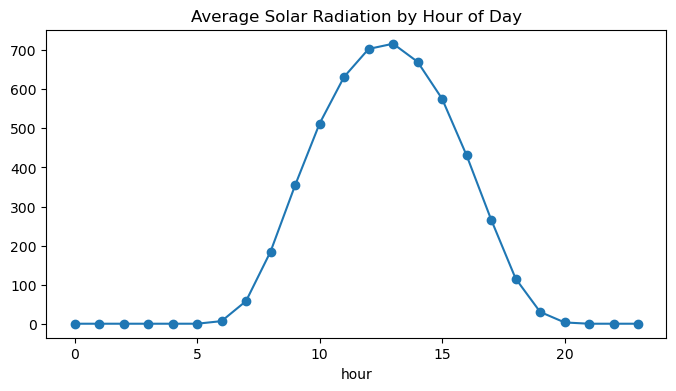

In [15]:
df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

hourly_avg = df.groupby('hour')['shortwave_radiation'].mean()
plt.figure(figsize=(8,4))
hourly_avg.plot(kind='line', marker='o')
plt.title('Average Solar Radiation by Hour of Day')
plt.savefig('../reports/figures/solar_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

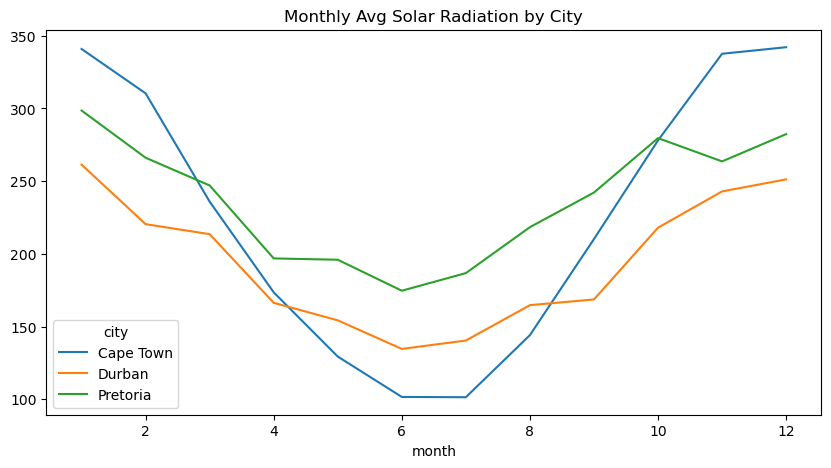

In [16]:
monthly = df.groupby(['city','month'])['shortwave_radiation'].mean().unstack(0)
monthly.plot(figsize=(10,5), title='Monthly Avg Solar Radiation by City')
plt.savefig('../reports/figures/solar_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

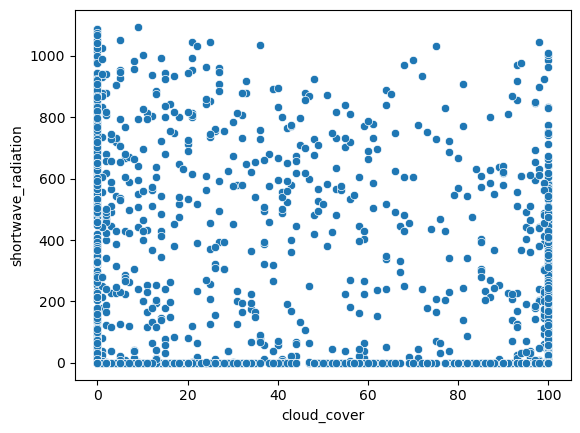

In [17]:
sns.scatterplot(data=df.sample(2000), x='cloud_cover', y='shortwave_radiation')
plt.savefig('../reports/figures/cloud_vs_solar.png', dpi=300, bbox_inches='tight')
plt.show()